In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

plt.rcParams['text.usetex'] = True

from utils import *

from scipy.optimize import curve_fit

# Model definition

In [2]:
N = 4
NB = N -1

omega_0 = 2
omega = .2
epsilon = .5

beta = 1

dt = 0.01
Nt = 500

In [3]:
Jx = np.zeros([2**NB,2**NB])
Jy = np.zeros([2**NB,2**NB])
Jz = np.zeros([2**NB,2**NB])
for j in range(NB):
    Jx = Jx + u_ith(X(),j,NB)/2
    Jy = Jy + u_ith(Y(),j,NB)/2
    Jz = Jz + u_ith(Z(),j,NB)/2
    
J2 = Jx@Jx + Jy@Jy + Jz@Jz

Jp = Jx+1j*Jy
Jm = Jx-1j*Jy

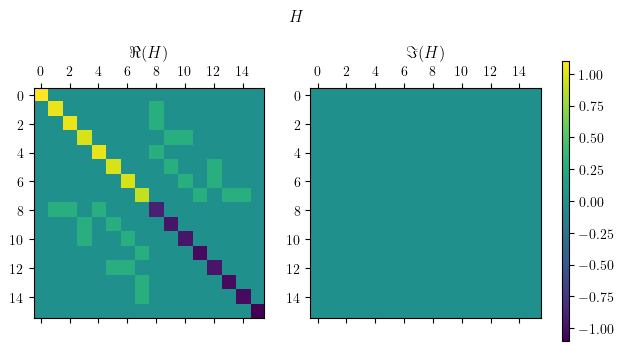

In [4]:
H_s = u_ith(Z(),0,N)*omega_0/2

H_int = (np.kron(X(),Jx) + np.kron(Y(),Jy))*epsilon/np.sqrt(NB)

H_e = omega/NB*Jz 

H = H_s + np.kron(np.eye(2),H_e)+ H_int

plot_matrix(H, 'H')

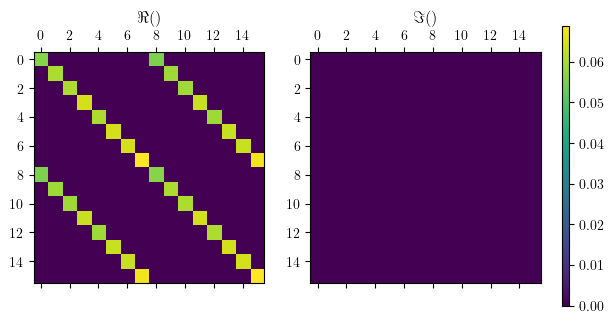

In [5]:
thermal = sp.linalg.expm(-beta*H_e)
thermal = thermal/np.trace(thermal)

vareps = 0.01
rho_s = (1-vareps)*np.ones([2,2])/2+vareps/2*np.array([[1,-1],[-1,1]])


rho_0 = np.kron(rho_s,thermal)

plot_matrix(rho_0)

# Simulation

In [6]:
ts = np.arange(Nt+1)*dt

## Original Model

In [7]:
def output(rho):
    return partial_trace(rho,2,2**NB)

Lvec = Lindblad_to_matrix(np.real(H),[])

x_0 = vec(rho_0)
    
A = sp.linalg.expm(Lvec*dt)

x_t = x_0

out = [output(unvec(x_t))]

for j in range(Nt):
    x_t = A@x_t
    out.append(output(unvec(x_t)))

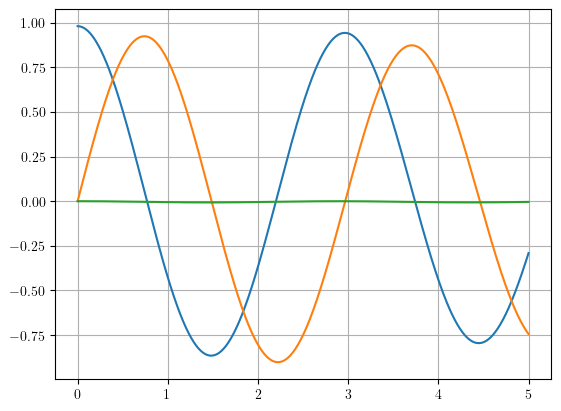

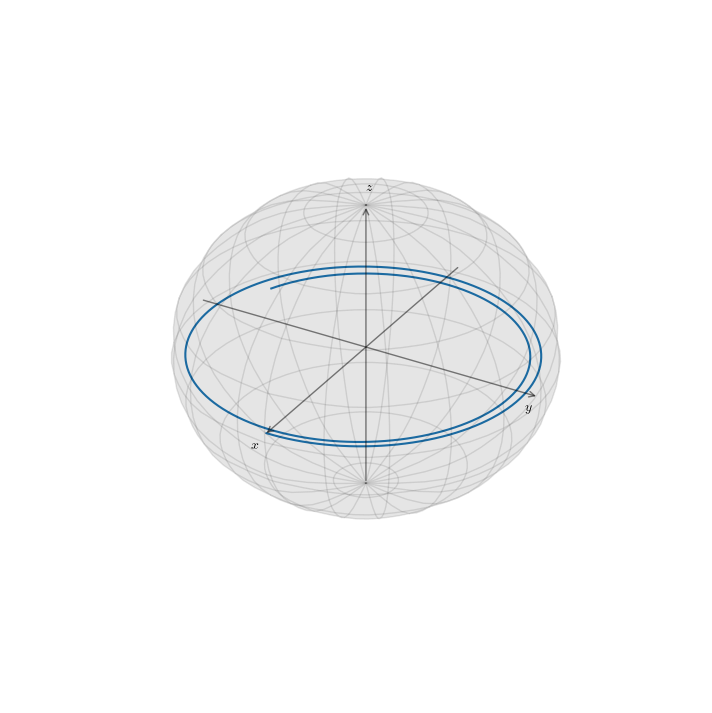

In [8]:
out = np.array(out)

xs = np.real(np.trace(out@X(),axis1=1,axis2=2)) 
ys = np.real(np.trace(out@Y(),axis1=1,axis2=2)) 
zs = np.real(np.trace(out@Z(),axis1=1,axis2=2)) 

plt.figure()
plt.plot(ts,xs)
plt.plot(ts,ys)
plt.plot(ts,zs)
plt.grid()
plt.show()


fig, ax = plot_bloch_shpere()
ax.plot(np.real(xs),np.real(ys),np.real(zs), alpha=1, label='Original model')
plt.show()

## Reduced model

In [9]:
def tr_E(X):
    return partial_trace(X,2,2**NB)

R = superoperator_to_matrix(tr_E, standard_base(2**N,2**N), standard_base(2,2))


def otimes_tau(X):
    return np.kron(X,thermal)

J = superoperator_to_matrix(otimes_tau, standard_base(2,2), standard_base(2**N,2**N))

In [10]:
m = 4

def get_Fs(L,J,R,order):
    Fs = [np.zeros([m,m])]

    for k in range(1,order+1):
        F = R@np.linalg.matrix_power(L,k)@J /math.factorial(k-1)
        C = np.zeros_like(F)
        for h in range(1,k):
            C += Fs[k-h]@R@np.linalg.matrix_power(L,h)@J /math.factorial(h)
        Fs.append(F - C)
    return Fs

def get_Es(Fs, M_max=50):
    Es = [np.eye(m)]
    for k in range(1,M_max):
        E = np.zeros([m,m], dtype=np.float64)
        for s in range(1,k+1):
            if s< len(Fs):
                E = E + Fs[s]@Es[k-s]/k
        Es.append(E)
    return Es

Fs = get_Fs(Lvec,J,R,20)
Es = get_Es(Fs, M_max=60)

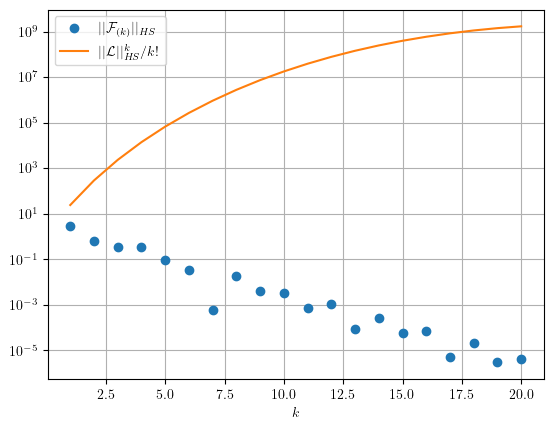

In [11]:
ks = np.arange(len(Fs))

def NORM(X):
    X = np.matrix(X)
    return np.real(np.sqrt(np.trace(X.H@X)))

norms_F = []
for F in Fs:
    norms_F.append(NORM(F))

theoretical = [0]
for k in ks[1:]:
    theoretical.append(NORM(Lvec)**k/math.factorial(k))

plt.figure()
plt.plot(ks[1:],norms_F[1:],'o',label=r'$||\mathcal{F}_{(k)}||_{HS}$')
plt.plot(ks[1:],theoretical[1:],label=r'$||\mathcal{L}||_{HS}^k/k!$')
plt.yscale('log')
plt.grid()
plt.legend()
plt.xlabel(r'$k$')
plt.show()


In [12]:
Ns = [1,2,3,4,10, 20]

data = [ts]
fit = []
output = []
for order in Ns:
    Es = get_Es(Fs[:order+1], M_max=100)

    xcm_0 = vec(partial_trace(rho_0,2,2**NB))

    es = []
    for E in Es:
        es.append(E@xcm_0)

    ys_mc = []
    for t in ts:
        xcm_t = np.zeros_like(xcm_0)
        for k,e in enumerate(es):
            xcm_t = xcm_t + e*(t**k)
        ys_mc.append(unvec(xcm_t))

    ys_mc = np.array(ys_mc)

    output.append(ys_mc)

    # error = []
    # for j in range(Nt+1):
    #     error.append(np.linalg.norm(ys[j,:]-ys_mc[j,:]))
    # error = np.array(error)

    # data.append(error)

    # plt.plot(ts,error, '-', label='N='+str(order))

    # def func(x, a):
    #     return a * x**(order-1)

    # popt, pcov = curve_fit(func, ts[100:400], error[100:400])
    # print(popt, pcov)

    # plt.plot(ts,func(ts,popt),':',label='N='+str(order)+' fit')
    # fit.append(func(ts,popt))

# plt.figure(figsize=(16/2,9/2))

# plt.grid()
# plt.yscale('log')
# plt.ylim([1e-16,1e3])
# plt.legend()
# plt.show()

# header = ['t']+['n'+str(k) for k in Ns] +['f'+str(k) for k in Ns] 
# df = pd.DataFrame(np.concatenate((np.array(data),np.array(fit))).T, columns=header)
# df.to_csv('../data/errors.csv',index=False)

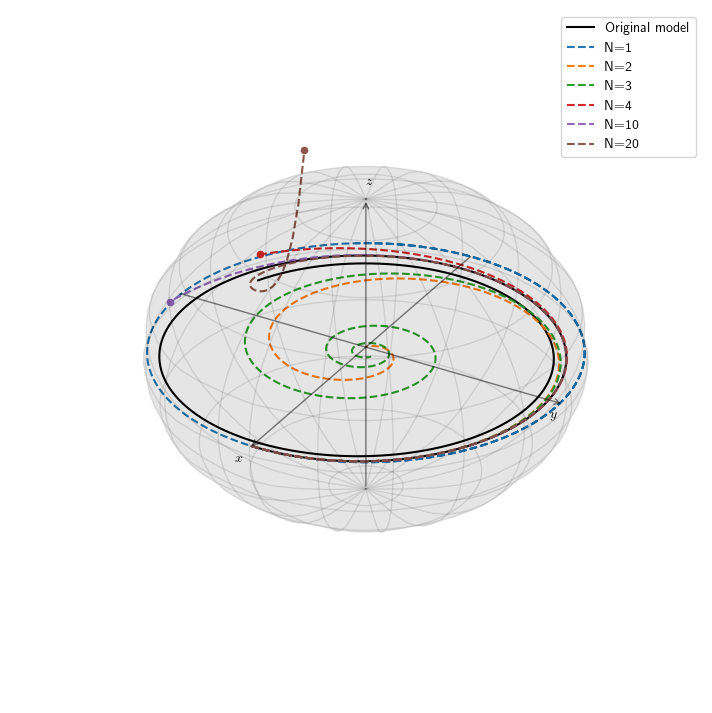

In [17]:
fig, ax = plot_bloch_shpere()
ax.plot(np.real(xs),np.real(ys),np.real(zs), 'k', alpha=1, label='Original model')

inds = []

for j, out_mc in enumerate(output):
    xs_mc = np.real(np.trace(out_mc@X(),axis1=1,axis2=2))
    ys_mc = np.real(np.trace(out_mc@Y(),axis1=1,axis2=2))
    zs_mc = np.real(np.trace(out_mc@Z(),axis1=1,axis2=2))
    rad = xs_mc**2 + ys_mc**2 + zs_mc**2
    err = np.where(rad>1)[0]
    if len(err)>0:
        ind = err[0]
    else:
        ind = Nt

    lines = ax.plot(np.real(xs_mc[:ind+1]),np.real(ys_mc[:ind+1]),np.real(zs_mc[:ind+1]),'--', label='N='+str(Ns[j]))
    linecolor = lines[0].get_color()
    if ind < Nt:
        ax.scatter(np.real(xs_mc[ind]),np.real(ys_mc[ind]),np.real(zs_mc[ind]),'--', color=linecolor)
    inds.append(ind)


ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
plt.legend()
plt.show()

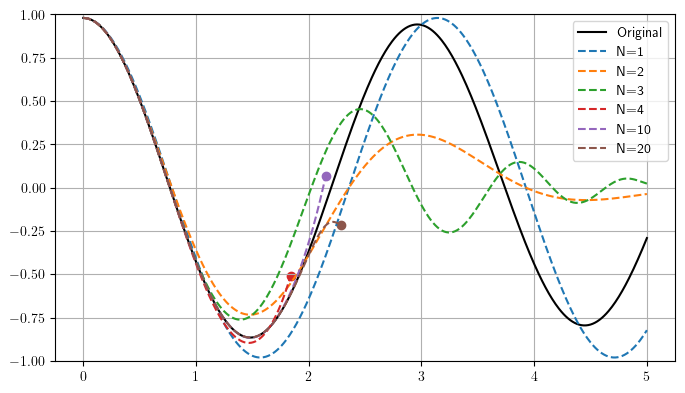

In [24]:
plt.figure(figsize=(16/2,9/2))
plt.plot(ts,xs,'k',label='Original')
for j, out_mc in enumerate(output):
    zs_mc = np.real(np.trace(out_mc@X(),axis1=1,axis2=2))
    lines = plt.plot(ts[:inds[j]+1],zs_mc[:inds[j]+1],'--',label='N='+str(Ns[j]))
    if inds[j]<Nt:
        linecolor = lines[0].get_color()
        plt.scatter(ts[inds[j]],zs_mc[inds[j]], color=linecolor)

plt.grid()
#plt.yscale('log')
plt.ylim([-1,1])

plt.legend()
plt.show()


[0.08254] [[3.58231e-06]]
[0.05777] [[6.75739e-07]]
[0.02993] [[1.0396e-07]]
[0.0113] [[1.10428e-08]]
[4.08544e-05] [[3.2401e-14]]
[2.43617e-08] [[2.97797e-21]]


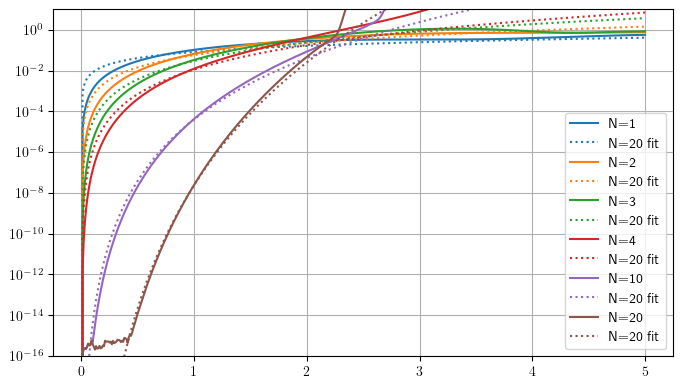

In [14]:
def distance(rho,tau):
    A = rho-tau
    return np.real(np.trace(sp.linalg.sqrtm(A.H@A)))

plt.figure(figsize=(16/2,9/2))
for j, out_mc in enumerate(output):
    error = []
    for k in range(out.shape[0]):
        error.append(distance(out[k,:,:],out_mc[k,:,:]))
    lines = plt.plot(ts,error,'-',label='N='+str(Ns[j]))
    def func(x, a):
         return a * x**(Ns[j])

    popt, pcov = curve_fit(func, ts[:100], error[:100])
    print(popt, pcov)
    linecolor = lines[0].get_color()
    plt.plot(ts,func(ts,popt),':',label='N='+str(order)+' fit', color=linecolor)
    # fit.append(func(ts,popt))

plt.grid()
plt.yscale('log')
plt.ylim([1e-16,10])
plt.legend()
plt.show()